In [27]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

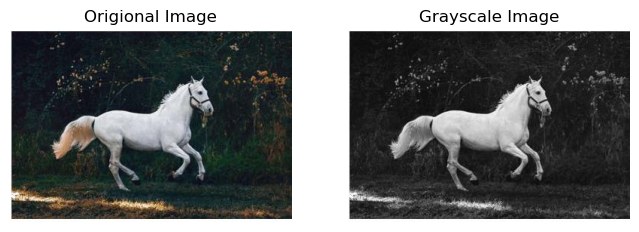

In [28]:
image = cv2.imread('horse.jpg')
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(image_rgb)
plt.title("Origional Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis('off')

plt.show()

In [29]:
pixel_values = image_rgb.reshape((-1, 3))
pixel_values = np.float32(pixel_values)

print("Shape of pixel array:", pixel_values.shape)

Shape of pixel array: (96000, 3)


In [30]:
k = 2
kmeans = KMeans(n_clusters=k, random_state=0)
labels = kmeans.fit_predict(pixel_values)
centers = np.uint8(kmeans.cluster_centers_)

print("Cluster centers:\n", centers)

Cluster centers:
 [[201 199 198]
 [ 30  37  36]]


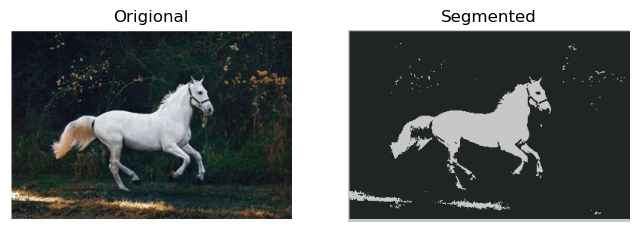

In [31]:
segmented_image = centers[labels.flatten()]
segmented_image = segmented_image.reshape(image_rgb.shape)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.title("Origional")
plt.imshow(image_rgb)
plt.axis("off")
plt.subplot(1,2,2)
plt.title("Segmented")
plt.imshow(segmented_image)
plt.axis("off")
plt.show()

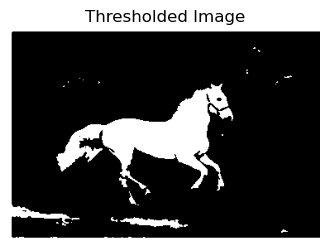

In [39]:
blur = cv2.GaussianBlur(gray, (3,3), 0)

_, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.figure(figsize=(4,4))
plt.imshow(thresh, cmap='gray')
plt.title("Thresholded Image")
plt.axis("off")
plt.show()

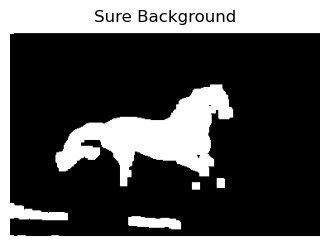

In [40]:
kernel = np.ones((3,3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

sure_bg = cv2.dilate(opening, kernel, iterations=2)

plt.figure(figsize=(4,4))
plt.imshow(sure_bg, cmap='gray')
plt.title("Sure Background")
plt.axis("off")
plt.show()

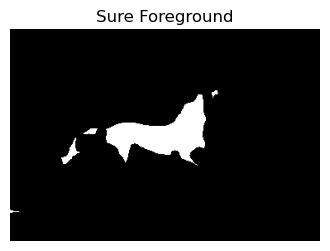

In [41]:
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)

_, sure_fg = cv2.threshold(dist_transform, 
                           0.2*dist_transform.max(), 255, 0)

plt.figure(figsize=(4,4))
plt.imshow(sure_fg, cmap='gray')
plt.title("Sure Foreground")
plt.axis("off")
plt.show()

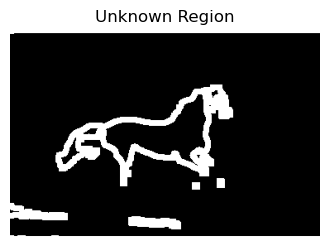

In [42]:
sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg, sure_fg)

plt.figure(figsize=(4,4))
plt.imshow(unknown, cmap='gray')
plt.title("Unknown Region")
plt.axis("off")
plt.show()

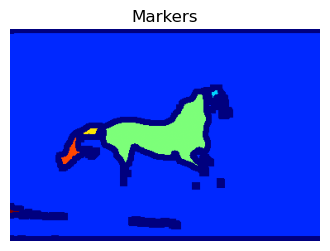

In [44]:
_, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown==255] = 0

plt.figure(figsize=(4,4))
plt.imshow(markers, cmap='jet')
plt.title("Markers")
plt.axis("off")
plt.show()

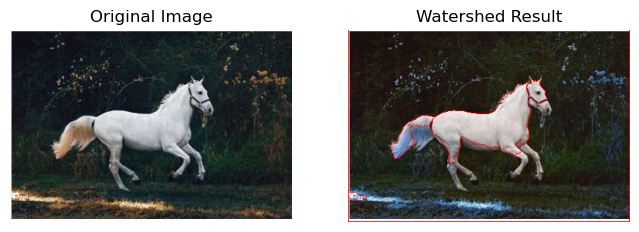

In [45]:
image_ws = image.copy()

markers = cv2.watershed(image_ws, markers)
image_ws[markers == -1] = [255, 0, 0]

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(image_rgb)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Watershed Result")
plt.imshow(image_ws)
plt.axis("off")
plt.show()

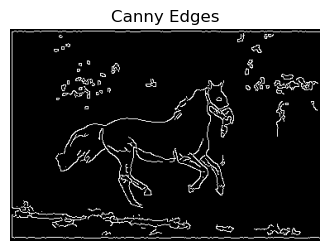

In [46]:
blur = cv2.GaussianBlur(gray, (5,5), 0)

edges = cv2.Canny(blur, 50, 150)

plt.figure(figsize=(4,4))
plt.imshow(edges, cmap='gray')
plt.title("Canny Edges")
plt.axis("off")
plt.show()

In [47]:
contours, _ = cv2.findContours(
    edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
)

print(f"Number of contours found: {len(contours)}")

Number of contours found: 98


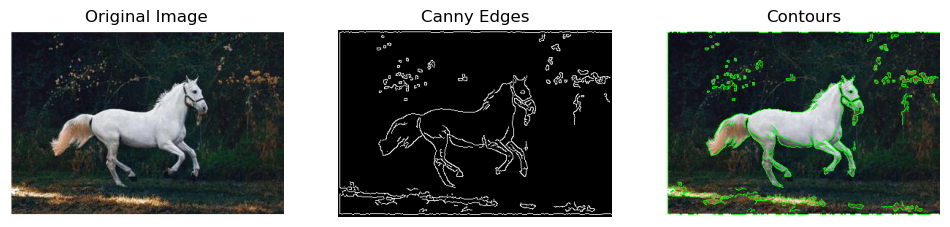

In [48]:
countour_image = image_rgb.copy()
cv2.drawContours(countour_image, contours, -1, (0,255,0), 1)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.title("Original Image")
plt.imshow(image_rgb)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Canny Edges")
plt.imshow(edges, cmap='gray')
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Contours")
plt.imshow(countour_image)
plt.axis("off")
plt.show()